##TP 2- Procesamiento de Archivos PDF-
Pellegrini Lucía


Elegí un PDF de la OMS, Salud mental y conexión social-
Informe del Director General

##**1-Adquisición y metadatos**

In [1]:
!pip install pdfplumber pymupdf pandas requests -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 69.9 MB/s eta 0:00:00


In [2]:
import pdfplumber
import pymupdf
import pandas as pd
import requests
import os

In [33]:
import requests

def download_pdf(url, filename):
  """Downloads a PDF file from a given URL.

  Args:
    url: The URL of the PDF file.
    filename: The name of the file to save the PDF as.
  """
  try:
    response = requests.get(url, stream=True) #solicitamos permiso a la url
    response.raise_for_status()

    with open(filename, 'wb') as file:
      for chunk in response.iter_content(chunk_size=8192):
        file.write(chunk)
    print(f"PDF downloaded successfully to {filename}")

  except requests.exceptions.RequestException as e:
    print(f"Error downloading PDF: {e}")


pdf_url = "https://apps.who.int/gb/ebwha/pdf_files/EB156/B156_8-sp.pdf"
output_filename = "B156_8-sp.pdf"

download_pdf(pdf_url, output_filename)

PDF downloaded successfully to B156_8-sp.pdf


In [4]:
! less B156_8-sp.pdf

%PDF-1.5^M%<E2><E3><CF><D3>
248 0 obj^M<</Linearized 1/L 208200/O 250/E 136310/N 6/T 207793/H [ 519 321]>>^M ^Mendobj^M             
270 0 obj^M<</DecodeParms<</Columns 5/Predictor 12>>/Filter/FlateDecode/ID[<A16E 3B6951A6FF479A13AD29167B3CAF><E453B9B4F576EF4DB737BDAC5DFD1D9E>]/Index[248 36]/I nfo 247 0 R/Length 107/Prev 207794/Root 249 0 R/Size 284/Type/XRef/W[1 3 1]>>str eam
h<DE>bbd`^P``b``<B6>^@<91>^L<8B>A$S^E<88>d<FD>^HfO^F<93><9F>^Qj<98>M<C1><E4>c0<F <F9>^],{^XD<B2>8<82>E<C0>*<99>TA$<A3>2<88><E4><8A>^B<91><F3><B6>^AIƪ<ED>`5b <D2> 3^P<AC>F^SH<FE><CF><DE><CB><C0>^DtI;<D8>^M^L<8C>^T<91><FF>^Y<98>x<BE>^B^D^X^@^S< <C5>^QS
endstream^Mendobj^Mstartxref
0
%%EOF
          
283 0 obj^M<</C 228/Filter/FlateDecode/I 251/Length 226/O 212/S 132>>stream
h<DE>b```^B<A2>U^L<AC>^L^L|^V^LB^L^H <C4><C0>^B^Tea<E0><98><E0> <D0><D0>0<E5>@<C <CD>^D<B1>      lvL<9B>^]^X^X<AA><AA>V<81>T0
|^N3=<BF><C0>u<E2><C6><F3>^\<9B>^S7<9E>?zH<A7>oM<F6>|<87>n3i<C3>rESC^F<8E><8E>^F ^F<B6>^N <C1><D1><C1><C0><A0>

**Modifico url para que me quede solo el pdf**

In [29]:
url_2 = "https://apps.who.int/gb/ebwha/pdf_files/EB156/B156_8-sp.pdf"

download_pdf(url_2, "B156_8-sp.pdf")

PDF downloaded successfully to B156_8-sp.pdf


In [34]:
! ls -lh   #aca incluye el tamaño del archivo

total 208K
-rw-r--r-- 1 root root 204K Oct  5 02:52 B156_8-sp.pdf
drwxr-xr-x 1 root root 4.0K Sep 16 13:26 sample_data


**Elijo PyMuPDF para abrir el Pdf**

In [7]:
# Prompt: Abrir el archivo PDF con PyMuPDF

doc = pymupdf.open("B156_8-sp.pdf")

print("Tipo de objeto:", type(doc))
print("Cantidad de páginas:", doc.page_count)

Tipo de objeto: <class 'pymupdf.Document'>
Cantidad de páginas: 6


**Metadatos con la misma librería**

In [21]:
metadata_mupdf = doc.metadata
metadata_mupdf

{'format': 'PDF 1.5',
 'title': 'Salud mental y conexión social',
 'author': 'VILLAGRA TORRES, Claudia',
 'subject': '',
 'keywords': '',
 'creator': 'Acrobat PDFMaker 15 for Word',
 'producer': 'Adobe PDF Library 15.0',
 'creationDate': "D:20250114172221+01'00'",
 'modDate': "D:20250114172223+01'00'",
 'trapped': '',
 'encryption': None}

In [9]:
numero_pagina = 5
pagina_mupdf = doc[numero_pagina]

print("Número de página (índice, PyMuPDF):", pagina_mupdf.number)
rect = pagina_mupdf.rect
print("Ancho:", rect.width, "- Alto:", rect.height)

Número de página (índice, PyMuPDF): 5
Ancho: 595.3200073242188 - Alto: 841.9199829101562


##**2-Análisis Estructural del Texto**

In [10]:
texto_completo_mupdf = ""

for pagina in doc:
    texto_pagina = pagina.get_text()
    if texto_pagina:
        texto_completo_mupdf += texto_pagina + "\n"

print("Cantidad de caracteres extraídos (PyMuPDF):", len(texto_completo_mupdf))
print("Cantidad de palabras aproximada:", len(texto_completo_mupdf.split()))

Cantidad de caracteres extraídos (PyMuPDF): 19410
Cantidad de palabras aproximada: 3061


In [11]:
#Prompt: Extraer el texto crudo del documento PDF página por página
texto_crudo = ""
for pagina in doc:
    texto_crudo += pagina.get_text("text") + "\n"

# Guardamos y mostramos una parte del resultado
print(f"Texto total extraído: {len(texto_crudo)} caracteres.\n")
print("--- Previsualización de los primeros 1000 caracteres ---")
print(texto_crudo[:1000])

Texto total extraído: 19410 caracteres.

--- Previsualización de los primeros 1000 caracteres ---
 
Consejo Ejecutivo 
156.ª reunión 
________________________________________________________________________________ 
Punto 8 del orden del día provisional 
 
EB156/8 
 
15 de enero de 2025 
________________________________________________________________________________ 
Salud mental y conexión social 
Informe del Director General 
1. 
En una reunión de la Mesa del Consejo Ejecutivo y el Director General celebrada en 
septiembre de 2024, y tras las peticiones realizadas por dos Estados Miembros, se formuló la 
recomendación de que se incluyera un punto sobre la salud mental y la conexión social en el orden 
del día provisional de la 156.ª reunión del Consejo Ejecutivo. En el presente informe se pone de 
relieve la necesidad de reforzar las medidas en materia de conexión social y salud mental y se 
describen las actividades e iniciativas recientes de la OMS que reflejan el compromiso polít

Análisis y separadores del texto

In [12]:
# Prompt: Analisis y separadores del texto extraído

import re

# 1. Buscar separadores visuales típicos (ej. líneas de guiones bajos que actúan como divisores)
lineas_separadoras = re.findall(r'_{10,}', texto_crudo)
print(f"Cantidad de líneas divisoras encontradas (_______): {len(lineas_separadoras)}")

# 2. Dividir el texto utilizando como criterio las páginas o saltos de página si existieran,
# o realizar un análisis de la estructura por párrafos divididos por líneas horizontales
secciones = re.split(r'_{10,}', texto_crudo)
print(f"El documento se ha dividido en {len(secciones)} secciones principales basadas en estas líneas.")

# Mostrar el inicio de cada sección identificada
for i, seccion in enumerate(secciones):
    lineas_seccion = [linea.strip() for linea in seccion.split('\n') if linea.strip()]
    if lineas_seccion:
        print(f"\nSección {i+1} - Primeras líneas:")
        print("\n".join(lineas_seccion[:3]))

Cantidad de líneas divisoras encontradas (_______): 2
El documento se ha dividido en 3 secciones principales basadas en estas líneas.

Sección 1 - Primeras líneas:
Consejo Ejecutivo
156.ª reunión

Sección 2 - Primeras líneas:
Punto 8 del orden del día provisional
EB156/8
15 de enero de 2025

Sección 3 - Primeras líneas:
Salud mental y conexión social
Informe del Director General
1.


Análisis de Estructura Interna

In [22]:
# Analizar la estructura interna de la Sección 3 (Cuerpo del informe)
cuerpo_texto = secciones[2]

# Encontrar los párrafos numerados (ej. '1. ', '2. ', al inicio de una línea)
parrafos_numerados = re.findall(r'\n(\d+)\.\s', cuerpo_texto)
print(f"Párrafos numerados identificados en el texto: {len(parrafos_numerados)}")
if parrafos_numerados:
    print(f"Rango de numeración: del {parrafos_numerados[0]} al {parrafos_numerados[-1]}")

# Separar el cuerpo del texto utilizando la numeración oficial como separador estructural
items_informe = re.split(r'\n(?=\d+\.\s)', cuerpo_texto)
print(f"Total de bloques/párrafos estructurados: {len(items_informe)}")

# Mostrar una pequeña muestra de los primeros 3 párrafos del cuerpo
print("\n--- MUESTRA DE PÁRRAFOS ESTRUCTURADOS ---")
for idx, item in enumerate(items_informe[:3]):
    fragmento = " ".join(item.strip().split())
    print(f"\n[Bloque {idx}] (Primeros 150 caracteres): {fragmento[:150]}...")

Párrafos numerados identificados en el texto: 23
Rango de numeración: del 1 al 23
Total de bloques/párrafos estructurados: 24

--- MUESTRA DE PÁRRAFOS ESTRUCTURADOS ---

[Bloque 0] (Primeros 150 caracteres): Salud mental y conexión social Informe del Director General...

[Bloque 1] (Primeros 150 caracteres): 1. En una reunión de la Mesa del Consejo Ejecutivo y el Director General celebrada en septiembre de 2024, y tras las peticiones realizadas por dos Est...

[Bloque 2] (Primeros 150 caracteres): 2. La salud social se refiere a la cantidad y calidad adecuadas de relaciones en un contexto determinado para satisfacer la necesidad de una persona d...


¿Qué caracteres actúan como separadores?

In [14]:
#Prompt: Identificar detalladamente los caracteres especiales que actúan como separadores
import re

print("=== ANÁLISIS DE CARACTERES SEPARADORES ===\n")

# 1. Separador de bloques de metadatos principales: El carácter de guion bajo '_'
lineas_guion = re.findall(r'_{5,}', texto_crudo)
print(f"[Separadores de Bloque de Cabecera]")
print(f"- Carácter: '_' (Guion bajo, Unicode 95)")
print(f"- Patrón detectado: Bloques repetidos de guiones bajos que actúan como líneas divisorias.")
print(f"- Total de líneas divisorias: {len(lineas_guion)}")
print(f"- Ejemplo visual de separación: Secciones divididas en el encabezado del documento.\n")

# 2. Separador de párrafos/bloques internos: Combinación de '\n' (Salto de línea) con números
saltos_parrafo = re.findall(r'\n\d+\.\s', texto_crudo)
print(f"[Separadores de Párrafos del Cuerpo]")
print(f"- Caracteres: '\n' (Salto de línea, Unicode 10) seguido de un número y punto ('1.', '2.', etc.)")
print(f"- Patrón detectado: Estructura jerárquica que define el inicio de un nuevo bloque de resolución.")
print(f"- Total de límites de párrafo oficiales detectados: {len(saltos_parrafo)}\n")

# 3. Separador de listas o viñetas internas: El carácter especial '•'
vinetas = re.findall(r'•', texto_crudo)
print(f"[Separadores de Listas Internas (Viñetas)]")
print(f"- Carácter: '•' (Bullet point, Unicode 8226)")
print(f"- Patrón detectado: Actúa como un separador de listas o subpuntos dentro de un mismo párrafo numerado.")
print(f"- Total de viñetas encontradas en el documento: {len(vinetas)}")

=== ANÁLISIS DE CARACTERES SEPARADORES ===

[Separadores de Bloque de Cabecera]
- Carácter: '_' (Guion bajo, Unicode 95)
- Patrón detectado: Bloques repetidos de guiones bajos que actúan como líneas divisorias.
- Total de líneas divisorias: 2
- Ejemplo visual de separación: Secciones divididas en el encabezado del documento.

[Separadores de Párrafos del Cuerpo]
- Caracteres: '
' (Salto de línea, Unicode 10) seguido de un número y punto ('1.', '2.', etc.)
- Patrón detectado: Estructura jerárquica que define el inicio de un nuevo bloque de resolución.
- Total de límites de párrafo oficiales detectados: 23

[Separadores de Listas Internas (Viñetas)]
- Carácter: '•' (Bullet point, Unicode 8226)
- Patrón detectado: Actúa como un separador de listas o subpuntos dentro de un mismo párrafo numerado.
- Total de viñetas encontradas en el documento: 9


##**3-Extracción de Datos Tabulares**





###Con PdfPlumber

¿Hay tablas estructuradas en este PDF?

In [35]:
import pdfplumber

# Abrir el PDF y buscar tablas estructuradas en cada página
with pdfplumber.open("B156_8-sp.pdf") as pdf:
    tablas_por_pagina = {}
    for i, pagina in enumerate(pdf.pages):
        tablas = pagina.extract_tables()
        if tablas:
            tablas_por_pagina[i + 1] = tablas

# Mostrar los resultados obtenidos
if tablas_por_pagina:
    print(f"Se encontraron tablas en las siguientes páginas: {list(tablas_por_pagina.keys())}")
    for num_pag, tablas in tablas_por_pagina.items():
        print(f"\n--- Tablas en la página {num_pag} ---")
        for idx, tabla in enumerate(tablas):
            print(f"Tabla {idx + 1}:")
            for fila in tabla:
                print(fila)
else:
    print("No se detectó ninguna tabla de datos estructurada con líneas divisorias o formato tabular en ninguna de las 6 páginas de este documento PDF.")

No se detectó ninguna tabla de datos estructurada con líneas divisorias o formato tabular en ninguna de las 6 páginas de este documento PDF.


##**4-Análisis de frecuencias (NLP básico)**

Tokenización con NLTK Por oraciones y por palabras

In [31]:
#PROMPT:quiero elegir la pagina 2 y realizar Tokenizacion con NLTK

import pymupdf
import nltk

# Descargar recursos necesarios de NLTK
nltk.download('punkt')
nltk.download('punkt_tab')

# Abrir el PDF
doc = pymupdf.open("B156_8-sp.pdf")

# La página 2 corresponde al índice 1
pagina_2 = doc[1]
texto_pagina_2 = pagina_2.get_text()

# Tokenización por oraciones
oraciones = nltk.sent_tokenize(texto_pagina_2, language='spanish')

# Tokenización por palabras
palabras = nltk.word_tokenize(texto_pagina_2, language='spanish')

# Mostrar resultados
print(f"--- TEXTO DE LA PÁGINA 2 (Primeros 300 caracteres) ---\n")
print(texto_pagina_2[:300] + "...")
print(f"\n--- RESULTADOS DE LA TOKENIZACIÓN ---")
print(f"Cantidad total de oraciones detectadas: {len(oraciones)}")
print(f"Cantidad total de palabras detectadas: {len(palabras)}")

print("\nPrimeras 3 oraciones extraídas:")
for idx, oracion in enumerate(oraciones[:3]):
    print(f"{idx + 1}: {oracion.strip()}")

print("\nPrimeras 15 palabras extraídas:")
print(palabras[:15])

--- TEXTO DE LA PÁGINA 2 (Primeros 300 caracteres) ---

EB156/8 
 
2 
 
5. 
La salud mental es un estado de bienestar mental que permite a las personas hacer frente a 
los momentos de estrés de la vida, desarrollar todas sus habilidades, poder aprender y trabajar 
adecuadamente y contribuir a la mejora de su comunidad. En la salud mental de una persona 
...

--- RESULTADOS DE LA TOKENIZACIÓN ---
Cantidad total de oraciones detectadas: 23
Cantidad total de palabras detectadas: 654

Primeras 3 oraciones extraídas:
1: EB156/8 
 
2 
 
5.
2: La salud mental es un estado de bienestar mental que permite a las personas hacer frente a 
los momentos de estrés de la vida, desarrollar todas sus habilidades, poder aprender y trabajar 
adecuadamente y contribuir a la mejora de su comunidad.
3: En la salud mental de una persona 
influyen factores propios del individuo (por ejemplo, la genética y factores cognitivos) y factores 
externos (como los recursos y las situaciones estresantes en su entorno s

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Limpieza Stop words

In [27]:
import nltk
from nltk.corpus import stopwords
import string

# Descargar el corpus de stopwords
nltk.download('stopwords')

# Obtener la lista de stop words en español
stop_words_es = set(stopwords.words('spanish'))

# Definir signos de puntuación adicionales
signos_puntuacion = set(string.punctuation + "¿" + "¡" + "•")

# Crear lista de palabras eliminadas
palabras_eliminadas = []

# Crear lista de palabras limpias
palabras_limpias = []

for palabra in palabras:
    if palabra.lower() in stop_words_es or palabra in signos_puntuacion or not palabra.isalnum():
        palabras_eliminadas.append(palabra)
    else:
        palabras_limpias.append(palabra)

# Mostrar estadísticas
print("=== RESULTADO DE LA LIMPIEZA ===\n")

print("Total de palabras originales:", len(palabras))
print("Total de palabras después de la limpieza:", len(palabras_limpias))
print("Total de palabras eliminadas:", len(palabras_eliminadas))

print("\nPalabras eliminadas:")
print(palabras_eliminadas)

print("\nPrimeras 30 palabras que quedaron:")
print(palabras_limpias[:30])

=== RESULTADO DE LA LIMPIEZA ===

Total de palabras originales: 654
Total de palabras después de la limpieza: 310
Total de palabras eliminadas: 344

Palabras eliminadas:
['EB156/8', '.', 'La', 'es', 'un', 'estado', 'de', 'que', 'a', 'las', 'a', 'los', 'de', 'de', 'la', ',', 'sus', ',', 'y', 'y', 'a', 'la', 'de', 'su', '.', 'En', 'la', 'de', 'una', 'del', '(', 'por', ',', 'la', 'y', ')', 'y', '(', 'como', 'los', 'y', 'las', 'en', 'su', ')', '.', 'A', ',', 'en', 'los', 'para', 'la', 'y', 'los', 'de', 'la', 'y', 'la', 'del', ',', 'en', 'las', 'que', ',', 'a', 'su', ',', 'los', '.', 'e', 'del', '.', 'El', 'y', 'la', 'a', 'de', 'las', 'en', 'las', 'del', '.', 'El', ',', 'es', 'en', 'las', ',', 'a', 'una', 'de', '.', 'Los', 'que', 'al', 'uno', 'de', 'está', 'o', 'se', 'siente', ',', 'es', 'que', 'se', 'esté', 'la', 'de', 'este', '.', 'la', 'y', 'el', 'a', ',', 'en', ',', 'hay', 'que', 'a', 'las', 'a', 'un', ',', 'como', 'los', 'de', 'y', '(', 'por', ',', 'la', ')', ',', 'la', ',', 'el', 'de'

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Visualización

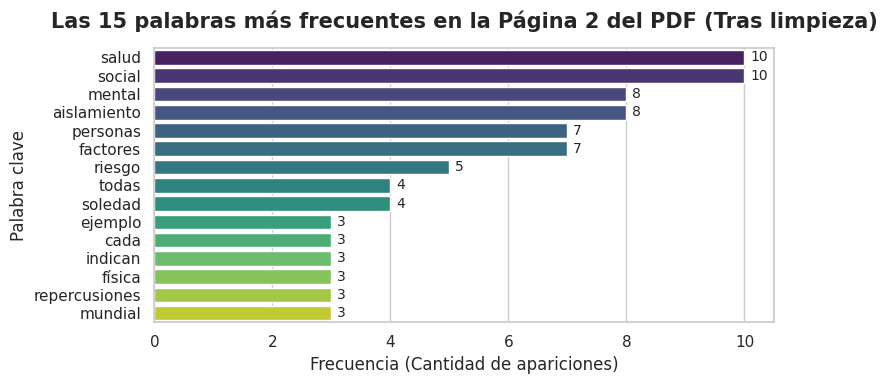

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

# Filtrar números sueltos (como '2' o '5' de las cabeceras/párrafos) para enfocarnos solo en palabras conceptuales relevantes
palabras_filtradas_final = [palabra for palabra in palabras_limpias if not palabra.isdigit()]

# Obtener las 15 palabras más comunes y sus frecuencias
contador_palabras = Counter(palabras_filtradas_final)
mas_comunes = contador_palabras.most_common(15)

# Convertir a un DataFrame de pandas para facilitar la graficación
df_frecuencias = pd.DataFrame(mas_comunes, columns=['Palabra', 'Frecuencia'])

# Configuración estética del gráfico
plt.figure(figsize=(8, 4))
sns.set_theme(style="whitegrid")

# Crear el gráfico de barras horizontal
ax = sns.barplot(
    x="Frecuencia",
    y="Palabra",
    data=df_frecuencias,
    palette="viridis",
    hue="Palabra",
    legend=False
)

# Añadir etiquetas con el valor exacto al final de cada barra
for p in ax.patches:
    width = p.get_width()
    plt.text(
        width + 0.1,
        p.get_y() + p.get_height() / 2,
        f'{int(width)}',
        ha="left",
        va="center",
        fontsize=10
    )

# Títulos y nombres de ejes
plt.title("Las 15 palabras más frecuentes en la Página 2 del PDF (Tras limpieza)", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Frecuencia (Cantidad de apariciones)", fontsize=12)
plt.ylabel("Palabra clave", fontsize=12)

# Ajustar diseño y mostrar el gráfico
plt.tight_layout()
plt.show()

Si considero que palabras como "cada", "todas", son stop word, ya que no les veo significancia por sí solas, pero claramente NLTK no las tomó como stop words.
Utilicé varios prompt en la parte de generar código y también saqué mucho código del Notebook de la clase "Taller introductorio a manipulación de archivos pdf"